In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(os.path.join("..")))
from src.preprocessing import (
    load_and_clean_data,
    prepare_data_for_training,
    get_preprocessor,
)
from src.plotting import (
    plot_distributions,
    plot_relationships,
    plot_advanced_features,
    plot_correlation_matrix,
)

In [2]:
# %% [markdown]
# ### 1. Identify and Load the Latest Dataset
# We query the `metadata.json` registry to find the most recent scraping session.

# %%
metadata_path = "../data/metadata.json"

if os.path.exists(metadata_path):
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    # Get the latest dataset based on 'scraped_at'
    latest_id = max(metadata.keys(), key=lambda k: metadata[k]["scraped_at"])
    latest_file = f"{latest_id}.csv"
    info = metadata[latest_id]

    print(f"Loading latest dataset: {latest_file}")
    print(f"Context: {info['property_type']} in {', '.join(info['cities'])}")

    dataset_path = os.path.join("..", "data", latest_file)
else:
    # Fallback if metadata doesn't exist
    dataset_path = "../data/dataset.csv"
    print("Metadata not found, trying default dataset.csv")

# Load and clean using modular logic
df = load_and_clean_data(dataset_path)
df.head()

Loading latest dataset: dataset_1775422174.csv
Context: flat in Beograd


,ID,City,Municipality,Neighborhood,Area,Rooms,Current_Floor,Total_Floors,Advertiser_Type,Photo_Count,...,Floor_Ratio,Area_per_Room,Rooms_per_100sqm,Area_Log,Photo_Count_Log,Is_Ground_Floor,Is_Top_Floor,Is_Agency,Floor_Category,Price_per_Unit_EUR
0,5425646907623,Beograd,Voždovac,Lekino brdo,73.06,3.0 Broj soba,II,5 Spratnost,Agencija,5,...,0.400000,24.353333,4.106214,4.304876,1.791759,0,0,1,Low,3950.000000
1,5425646877219,Beograd,Zvezdara,Mirijevo,58.48,2.5 Broj soba,II,4 Spratnost,Agencija,3,...,0.500000,23.392000,4.274966,4.085640,1.386294,0,0,1,Low,2402.530780
2,5425646821603,Beograd,Voždovac,Banjica,44.00,2.0 Broj soba,I,3 Spratnost,Agencija,5,...,0.333333,22.000000,4.545455,3.806662,1.791759,0,0,1,Low,3190.000000
3,5425646821602,Beograd,Voždovac,Banjica,61.41,3.0 Broj soba,I,3 Spratnost,Agencija,3,...,0.333333,20.470000,4.885198,4.133726,1.386294,0,0,1,Low,2800.000000
4,5425646898731,Beograd,Zvezdara,Mirijevo,33.00,1.0 Broj soba,I,5 Spratnost,Agencija,8,...,0.200000,33.000000,3.030303,3.526361,2.197225,0,0,1,Low,2636.363636


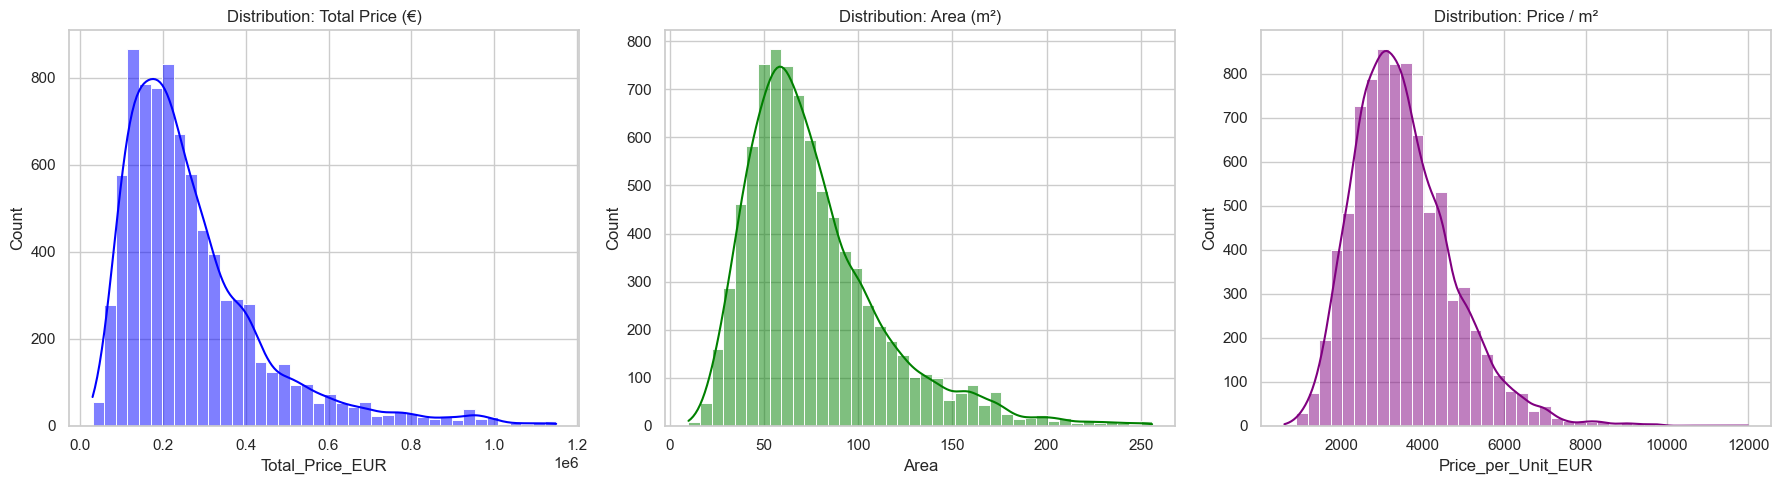

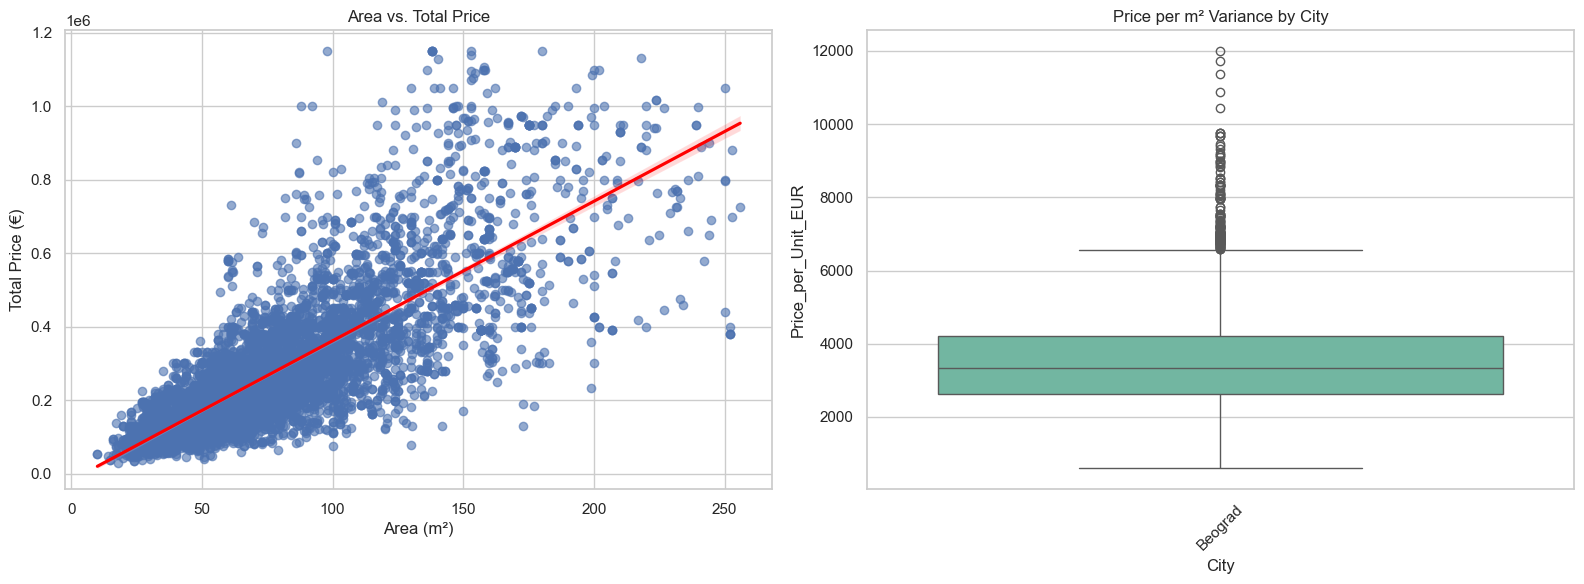

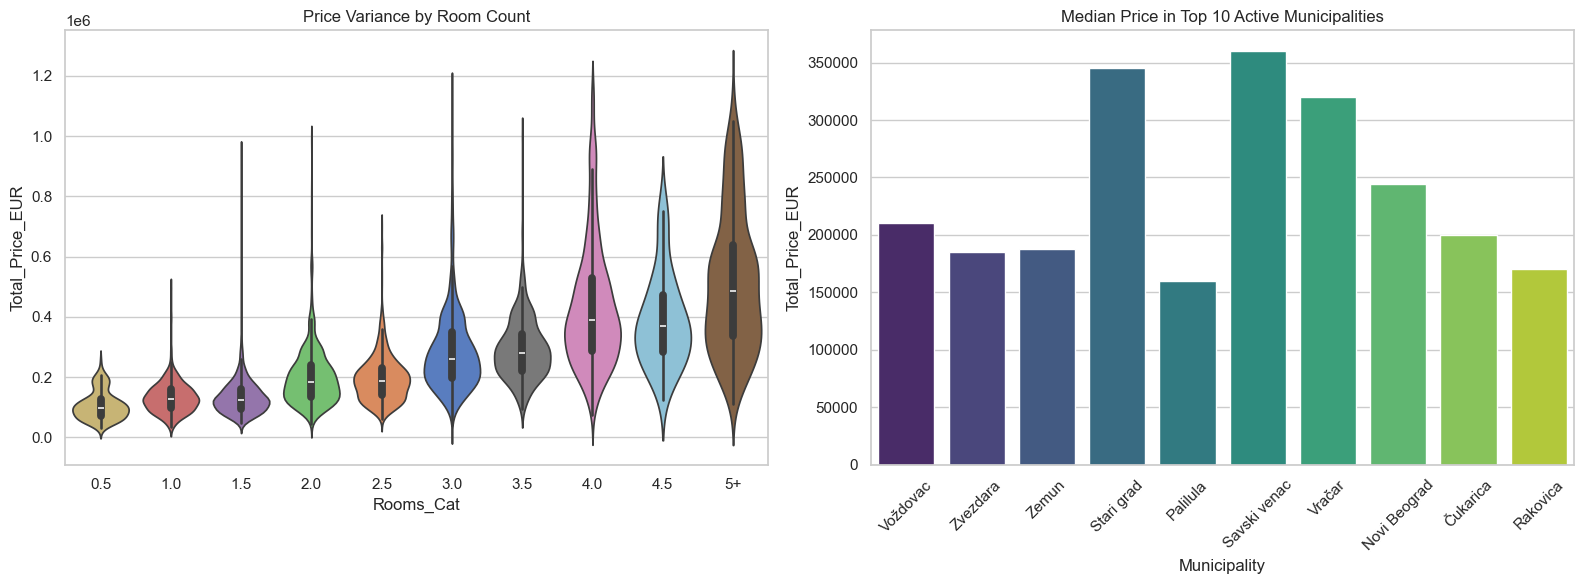

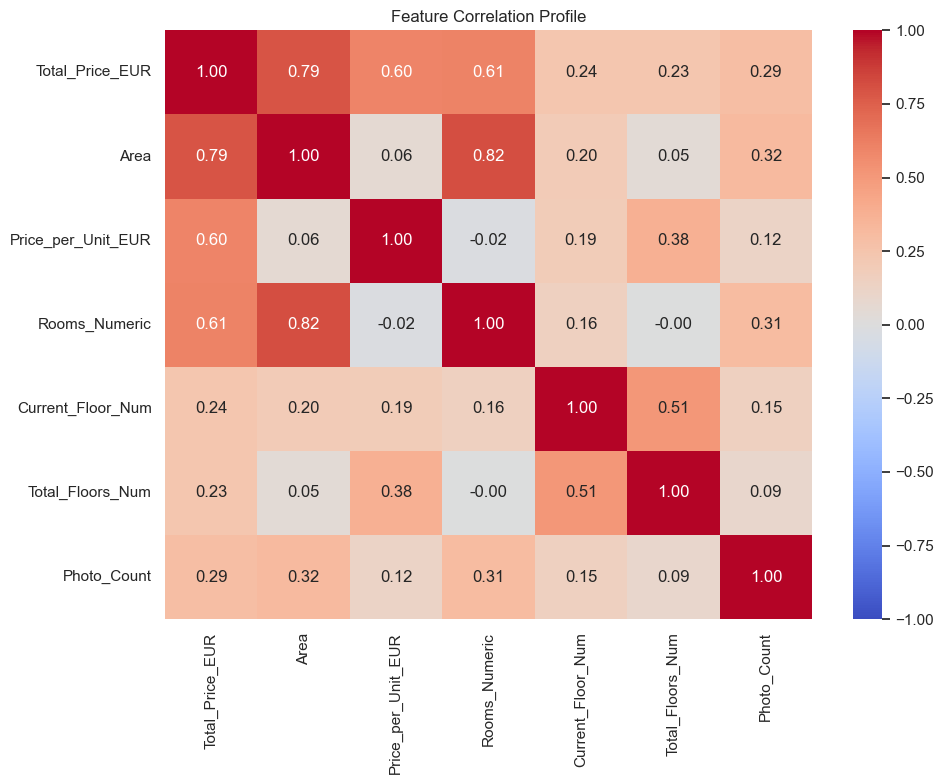

In [3]:
# %% [markdown]
# ### 2. Exploratory Data Analysis (EDA)
# Visualizing market trends, distributions, and feature synergies.

# %%
# Distributions of Price and Area
plot_distributions(df)
plt.show()

# Relationships between Area, Price, and City
plot_relationships(df)
plt.show()

# Room quantity and Municipality impact
plot_advanced_features(df)
plt.show()

# Correlation Heatmap
plot_correlation_matrix(df)
plt.show()

In [4]:
# %% [markdown]
# ### 3. Pipeline Simulation
# We use the `Pipeline` which encapsulates
# the `StandardScaler`, `OneHotEncoder`, and `Imputer`.

# %%
# 1. Separate features and target
target_col = "Total_Price_EUR"
X, y = prepare_data_for_training(df, target_col=target_col)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the dynamic preprocessor (detects columns automatically)
preprocessor = get_preprocessor(X_train)

# 4. Build and fit the Pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=100, random_state=42)),
    ]
)

print("Training the production-ready pipeline...")
model_pipeline.fit(X_train, y_train)

Training the production-ready pipeline...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('column_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer

In [5]:
# %% [markdown]
# ### 4. Evaluation
# Calculating performance metrics on the test set.

# %%
preds = model_pipeline.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"--- Model Evaluation ({target_col}) ---")
print(f"R-Squared Error: {r2:.4f}")
print(f"Mean Absolute Error: €{mae:,.2f}")

--- Model Evaluation (Total_Price_EUR) ---
R-Squared Error: 0.8688
Mean Absolute Error: €36,263.08


In [ ]:
# %% [markdown]
# ### 5. Manual Prediction Test
# Simulating a raw input like the Streamlit App would receive.

# %%
# Sample input (Area, Rooms, City, Municipality)
sample_input = pd.DataFrame(
    [
        {
            "Area": 65.0,
            "Rooms": 2.5,
            "City": "Beograd",
            "Municipality": "Zvezdara",
        }
    ]
)

# The pipeline handles all encoding/scaling internally
predicted_price = model_pipeline.predict(sample_input)[0]
print(f"Predicted Price for 65m2 flat in Zvezdara: €{predicted_price:,.2f}")

Predicted Price for 65m2 flat in Zvezdara: €209,865.97
